# PROCEDURE

## Description

 - Define the list of OSM `tags` to be included in the analysis
 - Define a EU study area `sa` by drawing a polygon at [geojson.io](http://geojson.io/#map=2/0/20)
 - Retrive satellite `products` from SentinelSat within `sa`, defining a time slice (fixed?)
 - Get the list of NUTS4 names `nuts_name` (PostGIS or EuroStat) within `sa`
 - Retrive OSM data for all `tags` for each `nuts_name`
 - Create annotations for `DL-model` using (Yolo/any) defined standard
 - Split `train` / `validation` / `testing`
 - Train the `DL-model`
 - Evaluate results on `testing` images

## Links

 - pyGIS :: https://pygis.io/docs/e_new_vectors.html# <br>

## Libraries

<b style="color:green">NOTES</b> <br>
 - when trying to uninstall you might get permission errors on files, restart the kernel since they could be in use in current notebook
 - ...

### Install

In [1]:
pip show numpy

Name: numpy
Version: 1.21.0
Summary: NumPy is the fundamental package for array computing with Python.
Home-page: https://www.numpy.org
Author: Travis E. Oliphant et al.
Author-email: None
License: BSD
Location: /home/jovyan/.rsm-msba/lib/python3.8/site-packages
Requires: 
Required-by: yfinance, xarray, tifffile, sos-r, sos-notebook, snuggs, sentinelhub, rioxarray, rasterio, pyogrio, pyarrow, pandas, osmnx, matplotlib, mapclassify, leafmap, folium, contourpy, bqplot, xgboost, torch, thinc, tensorflow, tensorboard, statsmodels, spacy, shap, seaborn, scipy, scikit-learn, scikit-image, PyWavelets, pyrsm, pyro-ppl, pyhdfe, PDPbox, patsy, opt-einsum, numexpr, numba, linearmodels, lime, lightgbm, Keras, keras-tuner, Keras-Preprocessing, imageio, h5py, gensim, eli5, cmdstanpy, blis, altair
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip show shapely

Name: Shapely
Version: 1.8.5
Summary: Geometric objects, predicates, and operations
Home-page: https://github.com/shapely/shapely
Author: Sean Gillies
Author-email: sean.gillies@gmail.com
License: BSD
Location: /home/jovyan/.rsm-msba/lib/python3.8/site-packages
Requires: 
Required-by: sentinelhub, osmnx, geopandas
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip show osmnx

Name: osmnx
Version: 1.2.0
Summary: Retrieve, model, analyze, and visualize OpenStreetMap street networks and other spatial data
Home-page: https://github.com/gboeing/osmnx
Author: Geoff Boeing
Author-email: boeing@usc.edu
License: MIT
Location: /home/jovyan/.rsm-msba/lib/python3.8/site-packages
Requires: networkx, requests, geopandas, Rtree, Shapely, pandas, matplotlib, pyproj, numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In order to install gdal I need to firstly install dependencies:

```BASH
sudo add-apt-repository ppa:ubuntugis/ppa && sudo apt-get update
sudo apt-get update
sudo apt-get install -y gdal-bin
sudo apt-get install -y libgdal-dev
export CPLUS_INCLUDE_PATH=/usr/include/gdal
export C_INCLUDE_PATH=/usr/include/gdal
```

Thenk install from within jupyter notebook:

```
pip install gdal
```

Installations that must be tested again:

### Load

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
# %load import.py
#
from IPython.display import IFrame

# 
import numpy as np
import pandas as pd

#
from sentinelsat import SentinelAPI, read_geojson, geojson_to_wkt
from datetime import date

#
import rioxarray
import geopandas as gpd
import rasterio as rio

#
from matplotlib import pyplot
from rasterio.plot import show

#
from sqlalchemy import create_engine # query PostGIS
from sqlalchemy import inspect

#
import osmnx as ox

#
from shapely.geometry import Polygon, box
import shapely.ops as so

#
import json

#
import os
from pathlib import Path
import fnmatch
import glob

#
from osgeo import gdal

#
import random

#
import shutil

#
from tqdm import tqdm
import time

#
import folium
from folium import plugins

#### Issues

## Study Area

In [4]:
# sa_fil = "italy_center_south.geojson"
sa_fil = "naples_metropolytan.geojson"

In [5]:
sa_j = read_geojson(sa_fil)

In [6]:
type(sa_j)

geojson.feature.FeatureCollection

In [8]:
sa = gpd.read_file(sa_fil)

In [9]:
type(sa)

geopandas.geodataframe.GeoDataFrame

<Axes: >

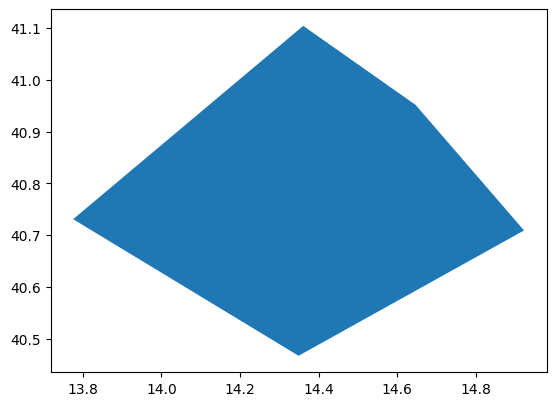

In [10]:
sa.plot()

## Prisma
https://www.asi.it/scienze-della-terra/prisma/

## SpaceNet
 - https://spacenet.ai/challenges/
 - https://spacenet.ai/sn7-challenge/

### Download data

```BASH
# run from within Mac terminal after configuring credentials:
aws s3 cp s3://spacenet-dataset/spacenet/SN7_buildings/tarballs/SN7_buildings_test_public.tar.gz spacenet/SN7/
aws s3 cp s3://spacenet-dataset/spacenet/SN7_buildings/tarballs/SN7_buildings_train.tar.gz spacenet/SN7/
aws s3 cp s3://spacenet-dataset/spacenet/SN7_buildings/tarballs/SN7_buildings_train_csvs.tar.gz spacenet/SN7/
```

## SentinelHub
 - [GitHub](https://github.com/sentinel-hub)
 - [User dashboard](https://apps.sentinel-hub.com/dashboard/#/configurations/92da91b8-dd15-4d37-a6e6-95bea2ef0796)

## SentinelSat

 - [SentinelSat.ipynb](./sentinelsat.ipynb)

## NUTS4

 - [nuts4.ipynb](./nuts4.ipynb)

## Open Street Map

- [osm.ipynb](./osm.ipynb)

## Annotations

- [annotations.ipynb](./annotations.ipynb)

## Deep Learning Modeling

- [DL_modeling.ipynb](./DL_modeling.ipynb)